# Module 8: Nonhomogeneous Poisson Processes by Thinning

In the standard Poisson process, events occur with a constant rate $\lambda$. This means that the expected number of events per unit time is the same throughout the observation period.

In many applications, the event rate changes over time. For example, messages, calls, requests, or arrivals may be more frequent during some parts of the day and less frequent during others. This motivates the nonhomogeneous Poisson process, where the rate is a function $\lambda(t)$.

This module simulates such a process using thinning. We first generate candidate events from a Poisson process with a constant upper rate. Then we keep or reject each candidate according to the value of $\lambda(t)$ at its event time.

## Model

Let $\lambda(t)$ be a nonnegative intensity function on a time interval $[0,T]$. A nonhomogeneous Poisson process is a counting process $N(t)$ such that the expected number of events in a small interval near time $t$ is approximately $\lambda(t)$ times the interval length.

For an interval $(a,b]$, the expected number of events is $\Lambda(a,b)=\int_a^b \lambda(s)\,ds$. The count $N(b)-N(a)$ has a Poisson distribution with mean $\Lambda(a,b)$.

### Thinning idea

Assume that $\lambda(t)\leq \lambda_{\max}$ for all $0\leq t\leq T$. We first simulate a homogeneous Poisson process with rate $\lambda_{\max}$. These event times are only candidates.

A candidate event at time $t$ is accepted with probability $\lambda(t)/\lambda_{\max}$. The accepted event times form a nonhomogeneous Poisson process with intensity $\lambda(t)$.

This construction is useful because it avoids solving the integral equation for the cumulative intensity function.

### Simulation rule

1. Choose a time interval $[0,T]$ and an intensity function $\lambda(t)$.
2. Choose a constant upper bound $\lambda_{\max}$ such that $\lambda(t)\leq \lambda_{\max}$.
3. Simulate candidate event times from a Poisson process with rate $\lambda_{\max}$.
4. For each candidate time $t$, generate a uniform random number $U$.
5. Accept the candidate if $U \leq \lambda(t)/\lambda_{\max}$.
6. Sort the accepted event times and build the counting process $N(t)$.

## Libraries




In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
FIGSIZE = (8, 4.5)
SMALL_FIGSIZE = (8, 3.5)
SUBPLOT_FIGSIZE = (8, 9)

HIST_ALPHA = 0.65
OVERLAP_ALPHA = 0.45

plt.rcParams["figure.figsize"] = FIGSIZE
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.frameon"] = False

plt.rcParams["lines.markersize"] = 4

# Random generator
rng = np.random.default_rng()

## Example 1: A time-varying intensity function

We start by defining an intensity function on a fixed time interval. The function is larger in the middle of the interval and smaller near the beginning and the end.

This can represent an arrival process with a busy period. For example, requests, messages, or calls may arrive more frequently during the middle of the day.

In [109]:
# End time of the observation interval
T = 24

# Baseline event rate
base_rate = 2.0

# Extra rate during the busy period
peak_rate = 6.0

# Center of the busy period
peak_center = 13.0

# Width of the busy period
peak_width = 4.0

def intensity(t):
    """Time-varying intensity function."""
    return base_rate + peak_rate * np.exp(
        -0.5 * ((t - peak_center) / peak_width) ** 2
    )

t_grid = np.linspace(0, T, 500)

# Intensity values on the grid
lambda_values = intensity(t_grid)

# Upper bound used for thinning
lambda_max = lambda_values.max()

print("Maximum intensity:", lambda_max)

Maximum intensity: 7.9999631026712725


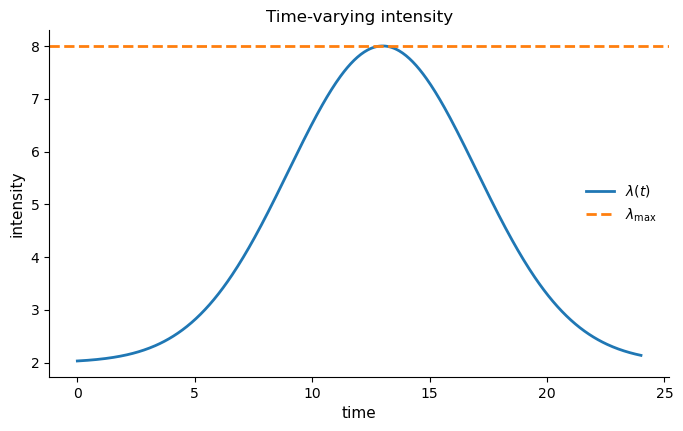

In [110]:
plt.figure(figsize=FIGSIZE)

plt.plot(
    t_grid,
    lambda_values,
    linewidth=2,
    label=r"$\lambda(t)$"
)

plt.axhline(
    lambda_max,
    color="C1",
    linestyle="--",
    linewidth=2,
    label=r"$\lambda_{\max}$"
)

plt.xlabel("time")
plt.ylabel("intensity")
plt.title("Time-varying intensity")
plt.legend()
plt.tight_layout()
plt.show()

The curve gives the event rate at each time. The dashed horizontal line is the constant upper rate used for thinning.

When $\lambda(t)$ is close to $\lambda_{\max}$, candidate events are likely to be accepted. When $\lambda(t)$ is small, many candidate events are rejected.

### Helper function

The next function simulates a nonhomogeneous Poisson process by thinning. It returns both candidate event times and accepted event times, so that the thinning step can be visualized.

In [111]:
def simulate_nhpp_thinning(T, intensity_func, lambda_max, rng=None):
    """Simulate a nonhomogeneous Poisson process by thinning."""
    if rng is None:
        rng = np.random.default_rng()

    # Store candidate event times
    candidate_times = []

    # Start at time 0
    current_time = 0.0

    while current_time < T:
        # Waiting time for the candidate Poisson process
        waiting_time = rng.exponential(1 / lambda_max)

        # Move to the next candidate event time
        current_time = current_time + waiting_time

        # Keep only candidate times inside the interval
        if current_time <= T:
            candidate_times.append(current_time)

    # Convert candidate times to a NumPy array
    candidate_times = np.array(candidate_times)

    # Acceptance probability at each candidate time
    accept_probabilities = intensity_func(candidate_times) / lambda_max

    # Uniform random numbers for accept/reject decisions
    uniforms = rng.random(len(candidate_times))

    # Accept candidates according to the thinning rule
    accepted = uniforms <= accept_probabilities

    # Split candidate times into accepted and rejected times
    accepted_times = candidate_times[accepted]
    rejected_times = candidate_times[~accepted]

    return candidate_times, accepted_times, rejected_times, accept_probabilities

## Example 2: One simulated path

We now simulate one nonhomogeneous Poisson process using thinning. The accepted event times are used to build the counting process $N(t)$.

The path is a step function. It jumps by one whenever an accepted event occurs.

In [112]:
# Simulate one nonhomogeneous Poisson process
candidate_times, accepted_times, rejected_times, accept_probabilities = simulate_nhpp_thinning(
    T=T,
    intensity_func=intensity,
    lambda_max=lambda_max,
    rng=rng
)

# Build the counting process from accepted event times
plot_times = np.concatenate(([0], accepted_times, [T]))
plot_counts = np.concatenate((
    [0],
    np.arange(1, len(accepted_times) + 1),
    [len(accepted_times)]
))

print("Number of candidate events:", len(candidate_times))
print("Number of accepted events:", len(accepted_times))
print("Number of rejected events:", len(rejected_times))

Number of candidate events: 199
Number of accepted events: 118
Number of rejected events: 81


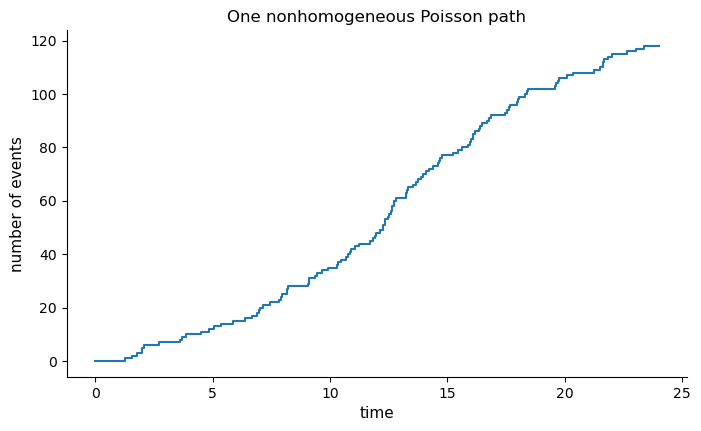

In [113]:
plt.figure(figsize=FIGSIZE)

plt.step(
    plot_times,
    plot_counts,
    where="post"
)

plt.xlabel("time")
plt.ylabel("number of events")
plt.title("One nonhomogeneous Poisson path")
plt.tight_layout()
plt.show()

This is one realization of the counting process. The jumps are not evenly spaced. More jumps tend to occur during the time interval where the intensity function is high.

The path should be read as one simulation, not as average behaviour.

## Example 3: Thinning construction

The previous example showed one simulated path of the nonhomogeneous Poisson process. Here we look more directly at how the thinning method constructs this path.

The idea is to first simulate candidate events from a homogeneous Poisson process with constant rate $\lambda_{\max}$. This rate is chosen as an upper bound for the time-dependent intensity, so that

$$
\lambda(t) \leq \lambda_{\max}, \qquad 0 \leq t \leq T.
$$

At each candidate time, the event is accepted with probability

$$
\frac{\lambda(t)}{\lambda_{\max}}.
$$

This means that candidate events are more likely to be accepted when the intensity $\lambda(t)$ is high, and less likely to be accepted when the intensity is low.

In the plot below, the curve shows the time-dependent intensity $\lambda(t)$, and the dashed horizontal line shows the upper bound $\lambda_{\max}$. The candidate points are placed under the rectangle determined by $[0,T]$ and $\lambda_{\max}$. Points below the intensity curve are accepted, while points above the curve are rejected.

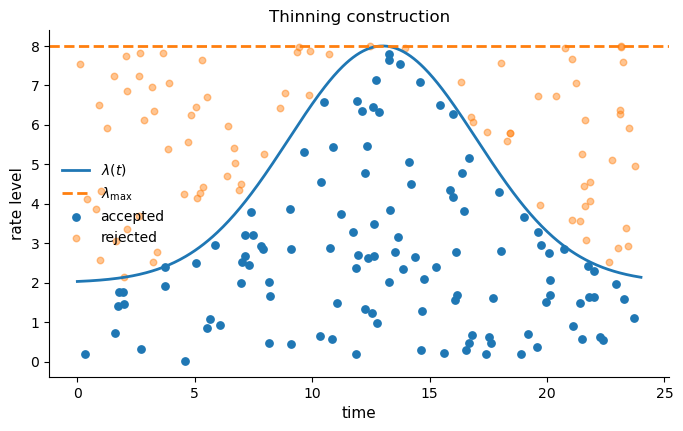

In [128]:
plt.figure(figsize=FIGSIZE)

# Random vertical marks used only for visualization.
# Accepted events are placed below the intensity curve.
accepted_heights = rng.random(len(accepted_times)) * intensity(accepted_times)

# Rejected events are placed between the intensity curve and the upper bound.
rejected_lower = intensity(rejected_times)
rejected_heights = rejected_lower + rng.random(len(rejected_times)) * (
    lambda_max - rejected_lower
)

plt.plot(
    t_grid,
    lambda_values,
    linewidth=2,
    label=r"$\lambda(t)$"
)

plt.axhline(
    lambda_max,
    color="C1",
    linestyle="--",
    linewidth=2,
    label=r"$\lambda_{\max}$"
)

plt.scatter(
    accepted_times,
    accepted_heights,
    s=28,
    label="accepted"
)

plt.scatter(
    rejected_times,
    rejected_heights,
    s=22,
    alpha=OVERLAP_ALPHA,
    label="rejected"
)

plt.xlabel("time")
plt.ylabel("rate level")
plt.title("Thinning construction")
plt.legend()
plt.tight_layout()
plt.show()

Accepted points are concentrated in the region where the intensity curve is high. Around the busy period, a larger part of the candidate region lies below the curve, so more candidate events are accepted. Near the beginning and the end of the interval, the intensity is lower, so more candidate events are rejected.

This plot gives a geometric view of the thinning rule. A homogeneous Poisson process first proposes candidate events at the constant rate $\lambda_{\max}$. The thinning step then keeps each candidate with probability $\lambda(t)/\lambda_{\max}$, producing a nonhomogeneous Poisson process with intensity $\lambda(t)$.

## Example 4: Many simulations and the mean count

A nonhomogeneous Poisson process has mean function $E[N(t)]=\Lambda(0,t)$, where $\Lambda(0,t)=\int_0^t \lambda(s)\,ds$.

We now repeat the simulation many times and compare the average simulated count with the theoretical mean curve.

In [125]:
# Use a fine grid for time values
t_grid_mean = np.linspace(0, T, 400)

# Evaluate the intensity function on the grid
lambda_grid_mean = intensity(t_grid_mean)

# Grid spacing
dt = t_grid_mean[1] - t_grid_mean[0]

# Approximate the cumulative intensity Lambda(0,t)
mean_curve = np.zeros_like(t_grid_mean)
mean_curve[1:] = np.cumsum(
    0.5 * (lambda_grid_mean[:-1] + lambda_grid_mean[1:]) * dt
)

print("Approximate expected total number of events:", mean_curve[-1])

Approximate expected total number of events: 107.94506966125316


In [126]:
# Number of independent simulations
n_runs = 1000

# Time grid used to record the counting process
t_grid_count = np.linspace(0, T, 200)

# Store the count path from each simulation
count_paths = []

for run in range(n_runs):
    # Simulate one nonhomogeneous Poisson process
    candidate_run, accepted_run, rejected_run, probs_run = simulate_nhpp_thinning(
        T=T,
        intensity_func=intensity,
        lambda_max=lambda_max,
        rng=rng
    )

    # Count accepted events up to each grid time
    count_path = np.searchsorted(
        accepted_run,
        t_grid_count,
        side="right"
    )

    count_paths.append(count_path)

# Convert to a 2D array: rows are simulations, columns are time points
count_paths = np.array(count_paths)

# Average count at each time
mean_count_sim = count_paths.mean(axis=0)

print("Number of simulations:", n_runs)
print("Average final count:", mean_count_sim[-1])

Number of simulations: 1000
Average final count: 108.253


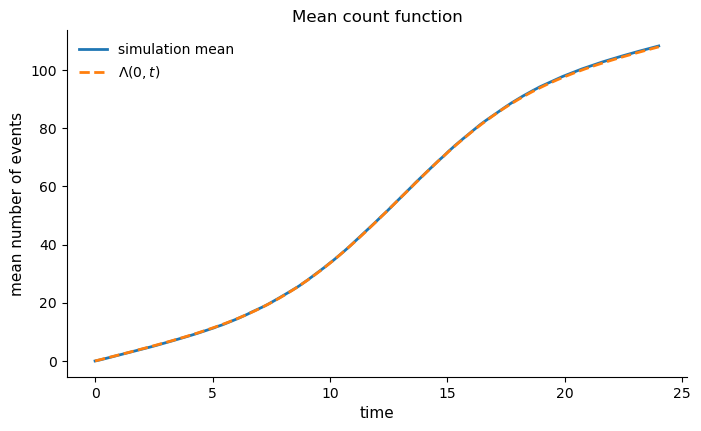

In [127]:
plt.figure(figsize=FIGSIZE)

plt.plot(
    t_grid_count,
    mean_count_sim,
    linewidth=2,
    label="simulation mean"
)

plt.plot(
    t_grid_mean,
    mean_curve,
    color="C1",
    linestyle="--",
    linewidth=2,
    label=r"$\Lambda(0,t)$"
)

plt.xlabel("time")
plt.ylabel("mean number of events")
plt.title("Mean count function")
plt.legend()
plt.tight_layout()
plt.show()

The solid curve is the average count from many simulations. The dashed curve is the theoretical mean function $\Lambda(0,t)$.

The two curves should be close when the number of simulations is large. This comparison checks that the thinning simulation produces the correct average event rate over time.

## Example 5: Event times and busy periods

The intensity function is highest near the middle of the interval. Accepted events should therefore appear more often near that time.

We compare this in two ways. A raster plot shows event times from several individual simulations, and a histogram summarizes event times collected from many simulations.

In [123]:
# Number of independent simulations
n_runs = 10000

# Store all accepted event times from all simulations
all_event_times = []

# Store a small number of paths for the raster plot
n_raster_paths = 25
raster_event_times = []

for run in range(n_runs):
    # Simulate one nonhomogeneous Poisson process
    candidate_run, accepted_run, rejected_run, probs_run = simulate_nhpp_thinning(
        T=T,
        intensity_func=intensity,
        lambda_max=lambda_max,
        rng=rng
    )

    # Store event times for the histogram
    all_event_times.extend(accepted_run)

    # Store only the first few paths for the raster plot
    if run < n_raster_paths:
        raster_event_times.append(accepted_run)

# Convert the list to a NumPy array
all_event_times = np.array(all_event_times)

print("Number of simulations:", n_runs)
print("Number of raster paths:", n_raster_paths)
print("Total number of accepted events:", len(all_event_times))

Number of simulations: 10000
Number of raster paths: 25
Total number of accepted events: 1079394


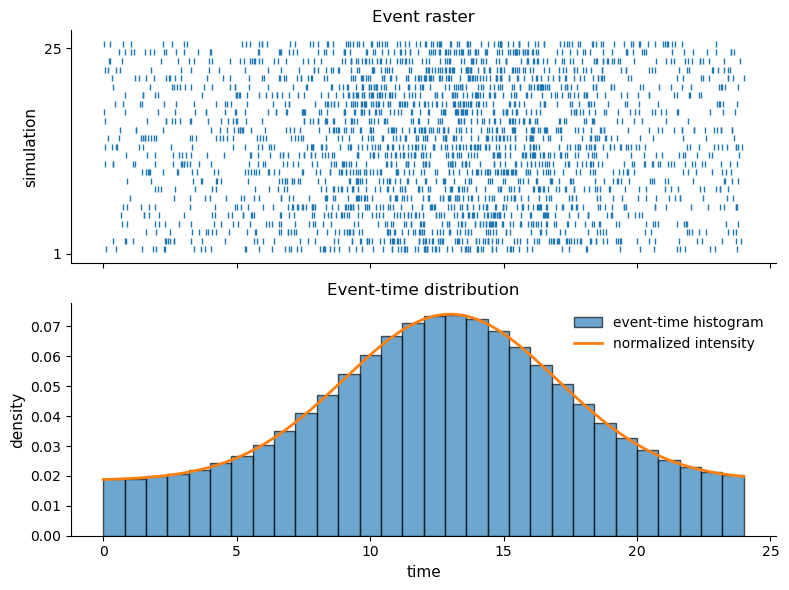

In [124]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# Raster plot of event times from a small number of simulations
for row, event_times in enumerate(raster_event_times):
    axes[0].vlines(
        event_times,
        row + 0.15,
        row + 0.85,
        linewidth=1
    )

axes[0].set_ylabel("simulation")
axes[0].set_title("Event raster")
axes[0].set_yticks([0, n_raster_paths - 1])
axes[0].set_yticklabels(["1", str(n_raster_paths)])

# Histogram of all accepted event times
axes[1].hist(
    all_event_times,
    bins=30,
    density=True,
    alpha=HIST_ALPHA,
    edgecolor="black",
    label="event-time histogram"
)

# Normalize the intensity curve for shape comparison
intensity_area = np.trapz(lambda_values, t_grid)
intensity_density = lambda_values / intensity_area

axes[1].plot(
    t_grid,
    intensity_density,
    color="C1",
    linewidth=2,
    label="normalized intensity"
)

axes[1].set_xlabel("time")
axes[1].set_ylabel("density")
axes[1].set_title("Event-time distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

The raster plot shows event times from several individual simulations. Each vertical mark represents one accepted event. Around the busy period, the marks become denser across different simulations.

The histogram combines event times from many simulations. The normalized intensity curve is added only for shape comparison. The event times are concentrated around the busy period, where $\lambda(t)$ is large. This makes the time-varying rate visible in the simulated event data.